<a href="https://colab.research.google.com/github/Lingeshkumar24-code/deep-learning/blob/main/CNN_img_proj_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Step 2: Preprocess and Normalize the Images
Action:

Resize all chest X-ray images to 224×224 pixels and normalize pixel values between 0 and 1.

Why:

CNN models require images of the same size and normalized pixel values for better learning.

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")
test_dir = os.path.join(path, "chest_xray", "test")

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

Step 3: Apply Image Augmentation
Action:

Generate augmented images during training using rotation, zooming, and flipping.

Why:

This increases dataset diversity and reduces overfitting.

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Step 4: Display Sample Images
Action:

Visualize some images from the training dataset.

Why:

This helps verify that the dataset has loaded correctly.

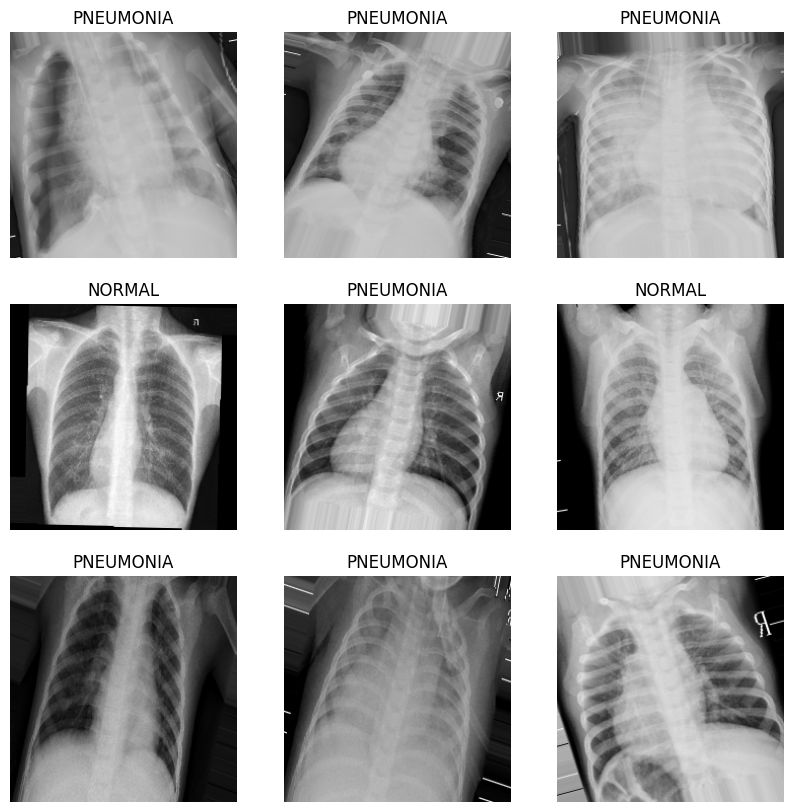

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i]==1 else "NORMAL")
    plt.axis("off")

plt.show()

Step 5: Define the CNN Model Architecture
Action:

Create a CNN with convolution, pooling, flatten, dense, and output layers.

Why:

CNN automatically extracts features from chest X-ray images.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

tep 6: Compile the CNN Model
Action:

Compile the model using Adam optimizer and Binary Crossentropy loss.

Why:

This prepares the model for training

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Step 7: Train the Model
Action:

Train the CNN using the training dataset and validate with the validation dataset.

Why:

The model learns to classify Normal and Pneumonia images.

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 149s 866ms/step - accuracy: 0.8273 - loss: 0.3976 - val_accuracy: 0.6250 - val_loss: 0.8806
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.8714 - loss: 0.2875 - val_accuracy: 0.7500 - val_loss: 0.5393
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.8911 - loss: 0.2671 - val_accuracy: 0.5625 - val_loss: 1.4370
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.9049 - loss: 0.2454 - val_accuracy: 0.6875 - val_loss: 0.9326
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.9122 - loss: 0.2137 - val_accuracy: 0.7500 - val_loss: 0.7725
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 653ms/step - accuracy: 0.9208 - loss: 0.2063 - val_accuracy: 0.6875 - val_loss: 0.8971
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 646ms/step - accuracy: 0.9275 - loss: 0.1875 - val_accuracy: 0.5625 - val_loss: 1.3148
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9388 -

Step 8: Evaluate and Predict
Action:

Evaluate the model on the test dataset and predict new chest X-ray images.

Why:

This measures the model's performance on unseen data.

In [ ]:

loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy*100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - accuracy: 0.8766 - loss: 0.4303
Test Accuracy: 87.66025900840759
